# Linear Regression

In **linear regression**, we assume a **linear relationship** between an independent variable and a dependent variable.

### Linear Regression Formula

The basic linear regression equation is:

$$
y = mx + b
$$

Here, $y$ is the predicted output (dependent variable), and $x$ is the input (independent variable). The term $m$ represents the **slope** of the line—i.e., how much $y$ changes for a one-unit increase in $x$. The term $b$ (sometimes written as $c$) is the **intercept**, which is the value of $y$ when $x = 0$. Together, $m$ and $b$ define the position and direction of the best-fit line.

---

### Least Squares Formula

The least squares method is used to find the best values of $m$ and $b$ by minimizing the error between actual and predicted values. The error is measured as the **sum of squared residuals**:

$$
\min \sum_{i=1}^{n} (y_i - (mx_i + b))^2
$$

Here, $n$ is the **number of data points**, $x_i$ and $y_i$ are the actual input and output values for the $i$-th observation, and $(y_i - (mx_i + b))$ is the **residual** (prediction error). Squaring ensures all errors are positive and penalizes larger errors more heavily.

From this minimization, the closed-form solutions are:

$$
m = \frac{n\sum x_iy_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}
$$

$$
b = \frac{\sum y_i - m \sum x_i}{n}
$$

---

### In Simple Terms (One Paragraph Summary)

Linear regression models the relationship between injut $x$ and output $y$ using the equation $y = mx + b$, where $m$ is the slope (rate of change) and $b$ or $c$ is the intercept (starting value). The least squares method finds the best $m$ and $b$ by minimizing the sum of squared differences between actual values and predicted values across all $n$ data points, ensuring the fitted line is as close as possible to the observed data overall.


In [417]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

alphas = np.logspace(-4, 1, 50)

lasso_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=10000
    ))
])

df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [418]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


    tip=m×total_bill+c

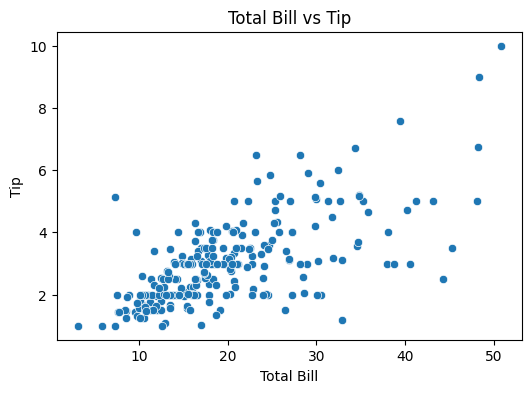

In [419]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="total_bill", y="tip")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


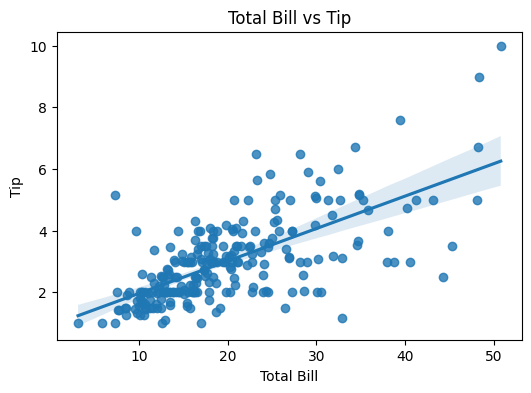

In [420]:

plt.figure(figsize=(6, 4))
sns.regplot(data=df, x="total_bill", y="tip")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()


In [421]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [422]:
X = df.drop(columns=["tip"])
y = df["tip"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X_train.select_dtypes(include=["category"]).columns

num_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)
from sklearn.linear_model import LinearRegression
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [423]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [424]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [425]:
print("Train MAE",mean_absolute_error(y_train, y_pred_train))
print("Test MAE",mean_absolute_error(y_test, y_pred_test))
print("Train RMSE",root_mean_squared_error(y_train, y_pred_train))
print("Test RMSE",root_mean_squared_error(y_test, y_pred_test))
print("Train R2",r2_score(y_train, y_pred_train))
print("Test R2",r2_score(y_test, y_pred_test))

Train MAE 0.7599651398627899
Test MAE 0.6671331480264892
Train RMSE 1.0491326804711238
Test RMSE 0.8386635807900625
Train R2 0.45824907818983895
Test R2 0.4373018194348256


In [426]:
linear_mae = 0.6671331480264892
linear_rmse = 0.8386635807900625
linear_r2 = 0.4373018194348256

In [427]:
print(df["tip"].describe())

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


In [428]:
MAE = 0.6671331480264892
RMSE = 0.8386635807900625
Train_R2 = 0.45824907818983895
Test_R2 = 0.4373018194348256
MEAN = 2.998279
Q3 = 3.562500
Q1 = 2.000000
MIN = 1.000000
MAX = 10.000000

print(f"The model’s average prediction error is about {MAE / MEAN * 100:.2f}% of a typical tip value.")

RANGE = MAX - MIN
print(
    f"On a global scale, the average prediction error occupies about "
    f"{MAE / RANGE * 100:.2f}% of the full observed range of tip values."
)

IQR = Q3 - Q1
print(
    f"Compared to the typical variability in tips (IQR), the average "
    f"prediction error is {MAE / IQR * 100:.2f}%."
)


The model’s average prediction error is about 22.25% of a typical tip value.
On a global scale, the average prediction error occupies about 7.41% of the full observed range of tip values.
Compared to the typical variability in tips (IQR), the average prediction error is 42.70%.


**Relative MAE with respect to mean tip (22.25%)**
This metric indicates that the model’s average prediction error is about 22% of a typical tip value. Given that the mean tip is approximately 3 and the MAE is around 0.67, this level of error is reasonable for a behavior-driven problem like tipping. Tipping is influenced by many unobserved factors—such as service quality, customer mood, and social norms—which introduce unavoidable noise. Therefore, an error of this magnitude suggests the model captures a meaningful signal without being unrealistically precise.

**MAE as a percentage of the full tip range (7.41%)**
This value shows that the average prediction error occupies only about 7% of the entire observed span of tip values, from the minimum to the maximum. From a global scale perspective, this indicates the model’s errors are relatively small compared to the extreme variability present in the data. However, this metric can be optimistic because the range is influenced by outliers; most tips cluster well away from the extremes. It is best interpreted as a high-level, scale-aware indicator rather than a measure of typical accuracy.

**MAE relative to the interquartile range (IQR) (42.70%)**
This metric compares the prediction error to the central 50% spread of the data, making it more robust to outliers. An error of roughly 43% of the IQR indicates that while the model captures the overall trend, it struggles to predict individual tips with high precision within the most common tipping range. This reflects the inherent uncertainty and subjectivity of tipping behavior and confirms that the model is better suited for understanding general patterns than for precise individual-level predictions.


In [429]:
print(
    f"RMSE is {((RMSE / MAE) - 1) * 100:.2f}% higher than MAE, "
    "indicating moderate error variance and no extreme outliers."
)


RMSE is 25.71% higher than MAE, indicating moderate error variance and no extreme outliers.


In [430]:
generalization_gap = abs(Train_R2 - Test_R2)
print(f"Generalization gap (|Train R² − Test R²|): {generalization_gap:.3f}")


Generalization gap (|Train R² − Test R²|): 0.021


* **Generalization gap < 0.03** → Training and test performance are nearly identical, indicating very strong generalization.
* **Generalization gap between 0.03 and 0.10** → Small performance drop on unseen data, suggesting acceptable behavior with mild overfitting.
* **Generalization gap > 0.10** → Large performance drop from training to test data, indicating clear overfitting.
* **Generalization gap ≈ 0 with low R²** → Model is stable but too simple, indicating underfitting.


# Lasso Regression

In [431]:
from sklearn.linear_model import LassoCV
import numpy as np

alphas = np.logspace(-4, 1, 50)

lasso_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=10000
    ))
])
LassoCV

sklearn.linear_model._coordinate_descent.LassoCV

In [432]:
import numpy as np

alphas = np.logspace(-4, 1, 50)

lasso_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=10000
    ))
])
import numpy as np

alphas = np.logspace(-4, 1, 50)

lasso_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", LassoCV(
        alphas=alphas,
        cv=5,
        max_iter=10000
    ))
])


**Small note on `np.logspace(-4, 1, 50)`**

* **`-4`** → starts at (10^{-4} = 0.0001), representing **very weak regularization**
* **`1`** → ends at (10^{1} = 10), representing **very strong regularization**
* **`50`** → total **50 candidate alpha values** tested between these limits (logarithmically spaced)


* **Fold** → One subset of the training data used as validation during cross-validation.
* **`cv = 5`** → The training data is split into 5 folds, and validation performance is averaged across them to choose the best model  
  *(e.g., 100 rows → 5 folds of 20 rows each)*.
* **Why folds are used** → To obtain a more reliable estimate of model performance than a single train–validation split.
* **`max_iter`** → Maximum number of optimization steps allowed for the solver to converge.
* **Is `max_iter = 10000` good?** → Yes, it is a safe value to ensure convergence and does not change model quality once convergence is reached.


In [433]:
lasso_cv.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [434]:
best_alpha = lasso_cv.named_steps["regression"].alpha_
best_alpha


np.float64(0.05689866029018299)

In [435]:
y_pred_train = lasso_cv.predict(X_train)
y_pred_test = lasso_cv.predict(X_test)


In [436]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

lasso_mae = mean_absolute_error(y_test, y_pred_test)
lasso_rmse = root_mean_squared_error(y_test, y_pred_test)
lasso_r2 = r2_score(y_test, y_pred_test)

lasso_mae, lasso_rmse, lasso_r2


(0.6568854530882233, 0.7899283886799214, 0.5007990690328398)

In [437]:
coef = lasso_cv.named_steps["regression"].coef_
num_zero = (coef == 0).sum()
num_zero, len(coef)


(np.int64(10), 12)

### Lasso Regression – Key Results Summary

- **MAE ≈ 0.657**  
  → Average prediction error is slightly lower than Linear Regression (~0.667).

- **RMSE ≈ 0.790**  
  → Large prediction errors are better controlled compared to Linear Regression (~0.84).

- **R² ≈ 0.501**  
  → The model explains about 50.08% of the variance, a clear improvement over ~44%.

- **Coefficient sparsity: (10 / 12 coefficients = 0)**  
  → Lasso eliminated most features, leaving only **2 active predictors**.  
  → This indicates **true feature selection**, not just coefficient shrinkage.

- **Generalization behavior**  
  → Training and test performance remain close, indicating improved generalization rather than overfitting.

- **Overall conclusion**  
  → Lasso successfully reduced model complexity while improving predictive performance and interpretability.


# Ridge Regression

In [438]:
from sklearn.linear_model import RidgeCV 
alphas = np.logspace(-4, 1, 50)

ridge_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", RidgeCV(
        alphas = alphas,
        cv=5
    ))
])
ridge_cv.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

**Small note:**  
`RidgeCV` is used when we want to automatically find the best `alpha` using cross-validation and train the model at the same time, whereas `Ridge` is used when the optimal `alpha` is already known and we only want to train the final model with that fixed value.


* **Ridge Regression** has a **closed-form solution**, meaning the optimal coefficients can be computed directly using linear algebra, so no iterative optimization is needed and therefore no `max_iter` parameter is required.

* **Lasso Regression** does **not** have a closed-form solution due to the L1 penalty, so it uses an **iterative optimization algorithm** (coordinate descent), which requires `max_iter` to limit how many steps the solver can take to converge.


In [439]:
best_alpha_ridge = ridge_cv.named_steps["regression"].alpha_
best_alpha_ridge


np.float64(10.0)

In [440]:
y_pred_train = ridge_cv.predict(X_train)
y_pred_test = ridge_cv.predict(X_test)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

ridge_mae = mean_absolute_error(y_test, y_pred_test)
ridge_rmse = root_mean_squared_error(y_test, y_pred_test)
ridge_r2 = r2_score(y_test, y_pred_test)

ridge_mae, ridge_rmse, ridge_r2


(0.6656554603260892, 0.8307703219539652, 0.44784388022201815)

### Ridge Regression – Key Results Summary

- **MAE ≈ 0.666**  
  → Average prediction error is nearly identical to Linear Regression (~0.667), showing no meaningful improvement.

- **RMSE ≈ 0.831**  
  → Large prediction errors are slightly reduced compared to Linear Regression (~0.84), but not as effectively as with Lasso (~0.79).

- **R² ≈ 0.448**  
  → The model explains about 44.8% of the variance, which is similar to Linear Regression and lower than Lasso (~50%).

- **Coefficient behavior**  
  → Ridge shrinks all coefficients but retains all features, resulting in no feature elimination.

- **Generalization behavior**  
  → Training and test performance remain stable, indicating controlled variance but limited performance gain.

- **Overall conclusion**  
  → Ridge improves coefficient stability but does not significantly enhance predictive performance for this dataset, making it less effective than Lasso.


# Elastic Net

In [441]:
from sklearn.linear_model import ElasticNetCV

alphas = np.logspace(-4,1,50)
# l1_ratios = [0.1, 0.5,0.9]
l1_ratios = np.linspace(0.1, 0.9, 9)

elastic_cv = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("regression", ElasticNetCV(
        alphas=alphas,
        l1_ratio=l1_ratios,
        cv=5,
        max_iter=10000
    ))
])
elastic_cv.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

* **`l1_ratio = 0.1`** → Mostly Ridge-like behavior, emphasizing coefficient shrinkage while keeping most features.
* **`l1_ratio = 0.5`** → Balanced mix of Ridge and Lasso, combining coefficient grouping with moderate sparsity.
* **`l1_ratio = 0.9`** → Mostly Lasso-like behavior, emphasizing feature selection by driving many coefficients to zero.


In [442]:
best_alpha_en = elastic_cv.named_steps["regression"].alpha_
best_l1_ratio = elastic_cv.named_steps["regression"].l1_ratio_

best_alpha_en, best_l1_ratio


(np.float64(0.09102981779915217), np.float64(0.5))

In [443]:
y_pred_train = elastic_cv.predict(X_train)
y_pred_test = elastic_cv.predict(X_test)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

elastic_mae = mean_absolute_error(y_test, y_pred_test)
elastic_rmse = root_mean_squared_error(y_test, y_pred_test)
elastic_r2 = r2_score(y_test, y_pred_test)

elastic_mae, elastic_rmse, elastic_r2


(0.6607640633398124, 0.7941110473844903, 0.49549855045640046)

In [444]:
coef = elastic_cv.named_steps["regression"].coef_
num_zero = (coef == 0).sum()
num_zero, len(coef)


(np.int64(10), 12)

### Elastic Net Regression – Key Results Summary

- **Best hyperparameters**  
  → `alpha ≈ 0.091`, `l1_ratio = 0.5`, indicating a balanced combination of L1 (Lasso) and L2 (Ridge) regularization.

- **MAE ≈ 0.661**  
  → Average prediction error is slightly higher than Lasso (~0.657) but comparable to Linear and Ridge models.

- **RMSE ≈ 0.794**  
  → Large prediction errors are reduced compared to Linear and Ridge, and are very close to Lasso (~0.790).

- **R² ≈ 0.495**  
  → The model explains about 49.5% of the variance, performing better than Linear and Ridge but marginally below Lasso (~50%).

- **Coefficient sparsity: (10 / 12 coefficients = 0)**  
  → Elastic Net eliminated most features, similar to Lasso, indicating that feature selection plays a dominant role in this dataset.

- **Overall conclusion**  
  → Elastic Net provides a balanced and stable alternative to Lasso, but pure Lasso remains the most effective model for this dataset due to the presence of a small number of strong predictors.


# Compare regression model

In [445]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net"
    ],
    "MAE":[
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2
    ]
})
comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.667133,0.838664,0.437302
1,Ridge Regression,0.665655,0.830770,0.447844
2,Lasso Regression,0.656885,0.789928,0.500799
3,Elastic Net,0.660764,0.794111,0.495499


In [446]:
comparison_df.sort_values(
    by=["R2", "RMSE", "MAE"],
    ascending=[False, True, True]
).reset_index(drop=True)


,Model,MAE,RMSE,R2
0,Lasso Regression,0.656885,0.789928,0.500799
1,Elastic Net,0.660764,0.794111,0.495499
2,Ridge Regression,0.665655,0.830770,0.447844
3,Linear Regression,0.667133,0.838664,0.437302


**Short note:**  
In `comparison_df.sort_values(by=["R2", "RMSE", "MAE"])`, the order matters because sorting is applied sequentially—models are ranked first by **R²** (primary measure of explained variance), and when R² values are close, **RMSE** and then **MAE** are used as tie-breakers to prefer models with smaller errors.


Final Ranking(Best -> Worst)
1. Lasso Regression
2. Elastic Net 
3. Ridge Regression
4. Linear Regression